In [1]:
import os
import subprocess

# Configure JuliaCall to use existing Julia installation
julia_exe = subprocess.check_output(["which", "julia"]).decode().strip()
os.environ["PYTHON_JULIACALL_EXE"] = julia_exe

# Use the CLANQS Julia project environment
clanqs_project = "/storage/niggeni/Documents/Projects/DataMiningRBMs/Netket/CLANQS"
os.environ["PYTHON_JULIACALL_PROJECT"] = clanqs_project

print(f"Using Julia: {julia_exe}")
print(f"Julia project: {clanqs_project}")
from juliacall import Main as jl

Using Julia: /storage/niggeni/.juliaup/bin/julia
Julia project: /storage/niggeni/Documents/Projects/DataMiningRBMs/Netket/CLANQS


/storage/niggeni/pyenv/venv/lib/python3.13/site-packages/juliacall/__init__.py:271: UserWarning: Julia was started with multiple threads but multithreading support is experimental in JuliaCall. It is recommended to restart Python with the environment variable PYTHON_JULIACALL_HANDLE_SIGNALS=yes set, otherwise you may experience segfaults or other crashes. Note however that this interferes with Python's own signal handling, so for example Ctrl-C will not raise KeyboardInterrupt. See https://juliapy.github.io/PythonCall.jl/stable/faq/#Is-PythonCall/JuliaCall-thread-safe? for further information. You can suppress this warning by setting PYTHON_JULIACALL_HANDLE_SIGNALS=no.
  warnings.warn(


Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython


In [2]:
import netket as nk
import numpy as np
from itertools import product
import copy
import matplotlib.pyplot as plt

In [3]:
def run_clifford_optimize(weights, paulis, script_path="clifford_optimize.jl", func_name="find_Clifford_for_plus_state"):
    """
    Run `func_name(weights, paulis)` from `script_path` using JuliaCall.

    Parameters
    ----------
    weights : list[float]
    paulis : list[str]
        NetKet Pauli string format (e.g., ["XXI", "IZZ", "ZIX"])
    script_path : str
    func_name : str

    Returns
    -------
    Tuple of (weights_julia, paulis_julia, clifford_op)
    """
    def _to_p_literal(p):
        s = str(p).strip()
        if s.startswith('P"') and s.endswith('"'):
            return s
        if s.startswith('"') and s.endswith('"'):
            s = s[1:-1]
        # Convert NetKet format (XXI) to Julia format (XX_)
        s = s.replace('I', '_')
        return f'P"{s}"'

    # NetKet weights can be complex with tiny imaginary noise; Julia parser can't read Python 'j' literals.
    # Convert to real scalars before building the Julia expression.
    weights_real = []
    for w in weights:
        w_complex = complex(w)
        if abs(w_complex.imag) > 1e-10:
            raise ValueError(f"Clifford optimization expects real weights, got {w_complex}")
        weights_real.append(float(w_complex.real))

    weights_expr = "[" + ", ".join(f"{w:.17g}" for w in weights_real) + "]"
    paulis_expr = "[" + ", ".join(_to_p_literal(p) for p in paulis) + "]"

    jl.include(script_path)
    jl.seval(f"_py_weights = {weights_expr}")
    jl.seval(f"_py_paulis = {paulis_expr}")

    return jl.seval(f"{func_name}(_py_weights, _py_paulis)")


def clifford_optimize_netket_operator(op, script_path="clifford_optimize.jl"):
    """
    Apply Clifford optimization to a NetKet PauliStrings operator.

    Parameters
    ----------
    op : nk.operator.PauliStrings or nk.operator.LocalOperator
        The input NetKet operator to optimize
    script_path : str
        Path to the Julia clifford_optimize.jl script

    Returns
    -------
    nk.operator.PauliStrings
        The Clifford-optimized operator
    """
    # Accept either PauliStrings or LocalOperator-like objects.
    if hasattr(op, "to_pauli_strings"):
        op = op.to_pauli_strings()

    # Extract Pauli strings and weights from NetKet operator
    paulis_str = list(op.operators)
    weights = list(op.weights)

    # Run Clifford optimization
    weights_julia, paulis_julia, clifford_op = run_clifford_optimize(weights, paulis_str, script_path=script_path)

    # Convert Julia result back to NetKet format
    weights_nk = [float(complex(w).real) for w in list(weights_julia)]
    paulis_nk = []
    phases = []

    for p in paulis_julia:
        p_str = str(p).strip()
        # Extract phase and Pauli part
        if p_str.startswith('+ '):
            phases.append(1.0)
            pauli = p_str[2:].strip()
        elif p_str.startswith('- '):
            phases.append(-1.0)
            pauli = p_str[2:].strip()
        else:
            phases.append(1.0)
            pauli = p_str.strip()

        # Replace underscores with I for identity
        pauli = pauli.replace('_', 'I')
        paulis_nk.append(pauli)

    # Incorporate phases into weights
    weights_nk = [w * ph for w, ph in zip(weights_nk, phases)]

    # Create and return NetKet PauliStrings operator
    op_optimized = nk.operator.PauliStrings(paulis_nk, weights_nk)
    return op_optimized

In [4]:
from netket.operator.spin import sigmax, sigmay, sigmaz
def get_site(g,i,translation):
    return g.id_from_position(g.positions[i] + translation)

def get_J1J2kagome_Hamiltonian(J1, J2, Lx, Ly, pbc = True):
    """
    Constructs a Heisenberg Hamiltonian on a kagome lattice. J2 is a tunable frustrated bond, see https://doi.org/10.1038/s41467-020-15402-w
    Returns:
        g: NetKet Lattice object
        hi: NetKet Hilbert space
        H: NetKet Hamiltonian operator
    """
    # Kagome lattice: 3-site basis, triangular Bravais lattice
    a1 = [1, 0]
    a2 = [0.5, np.sqrt(3)/2]
    site_offsets = [[0, 0], [1/2, 0], [1/4, np.sqrt(3)/4]]

    g = nk.graph.Lattice(
        basis_vectors=[a1, a2],
        site_offsets=site_offsets,
        pbc=pbc,
        extent=[Lx, Ly]
    )


    J1_bonds = [a1, a2]
    J2bonds = [0.5*np.array([0.5, -np.sqrt(3)/2])]
    
    hi = nk.hilbert.Spin(s=1/2, N=g.n_nodes)
    H = 0
    
    for i in g.nodes():
        for t in J1_bonds:
            j = get_site(g, i, t)
            H += J1 * S_S(hi, i, j)

        _,_,subl = g.basis_coords[i]
        if subl == 0: #0 type sites do not have a J2 bond
            continue
        for t in J2bonds:
            j = get_site(g, i, t)
            H += J2 * S_S(hi, i, j)

    return g, hi, H
def S_S(hi, i, j):
    return (sigmax(hi, i) * sigmax(hi, j) + sigmay(hi, i) * sigmay(hi, j) + sigmaz(hi, i) * sigmaz(hi, j))


In [154]:
J1 = 1.0
J2 = 1.0
# Create the Hamiltonian
N_iters = 4000
# N_Samples = np.inf
N_Samples = 2**12

learning_rate = 0.002
diag_shift = 8e-3
RBMAlpha = 3
Lx = 4
Ly = 4

H_kagome = get_J1J2kagome_Hamiltonian(J1=J1, J2=J2, Lx=Lx, Ly=Ly, pbc=True)[2]
H_kagome_pauli = H_kagome.to_pauli_strings()
op_kagome = clifford_optimize_netket_operator(H_kagome_pauli)
N_sites = H_kagome.hilbert.size
print(f"Kagome lattice with {N_sites} sites")
print(f"using N_Samples = {N_Samples} RBMAlpha = {RBMAlpha} learning_rate = {learning_rate} diag_shift = {diag_shift} for SR")
print(f"Number of Pauli terms: {len(op_kagome.operators)}")
print(f"\nFirst few terms:")
for i, (op, w) in enumerate(zip(op_kagome.operators[:5], op_kagome.weights[:5])):
    print(f"  {op}: {w:.4f}")

Kagome lattice with 48 sites
using N_Samples = 4096 RBMAlpha = 3 learning_rate = 0.002 diag_shift = 0.008 for SR
Number of Pauli terms: 384

First few terms:
  XIIIIIIIIIIIXIIIIIIIIIIIXIIIIIIIIIIIXIIIIIIIIIII: 1.0000
  YIIIIIIIIIIIXIIIIIIIIIIIYIIIIIIIIIIIXIIIIIIIIIII: 1.0000
  ZIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIIIIIIIIIIIIIII: 1.0000
  XIIXIIIIIIIIXIIXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII: 1.0000
  YIIYIIIIIIIIXIIXIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII: 1.0000


In [155]:
# Train RBM on original Hamiltonian
print("\n" + "="*60)
print("Training RBM on ORIGINAL Hamiltonian")
print("="*60)

hilbert = op_kagome.hilbert
model = nk.models.RBM(alpha=RBMAlpha, param_dtype=np.complex64)

if N_Samples == np.inf:
    vstate = nk.vqs.FullSumState(hilbert, model)
else :
    vstate = nk.vqs.MCState(sampler=nk.sampler.MetropolisLocal(hilbert), model=model, n_samples=N_Samples)

optimizer = nk.optimizer.Sgd(learning_rate=learning_rate)
sr = nk.optimizer.SR(diag_shift=diag_shift,holomorphic=True)

driver = nk.VMC(
    hamiltonian=op_kagome,
    optimizer=optimizer,
    variational_state=vstate,
    preconditioner=sr,
)

log_original = nk.logging.RuntimeLog()
driver.run(n_iter=N_iters, out=log_original)

energy_original = vstate.expect(op_kagome)
print(f"\nFinal energy (original): {energy_original.mean:.6f}")


Training RBM on ORIGINAL Hamiltonian


  0%|          | 0/4000 [00:00<?, ?it/s]


Final energy (original): -152.003850+0.033490j


In [156]:
# Apply Clifford optimization to the Hamiltonian
print("\n" + "="*60)
print("Applying Clifford Optimization")
print("="*60)

try:
    op_clifford = clifford_optimize_netket_operator(op_kagome, script_path="clifford_optimize.jl")
    print("Clifford optimization successful!")
    print(f"Original number of terms: {len(op_kagome.operators)}")
    print(f"Clifford-optimized number of terms: {len(op_clifford.operators)}")
    print(f"\nClifford-optimized Hamiltonian (first 10 terms):")
    for i, (op, w) in enumerate(zip(op_clifford.operators[:10], op_clifford.weights[:10])):
        print(f"  {op}: {w:.4f}")
except Exception as e:
    print(f"Clifford optimization failed: {e}")
    print("Using original Hamiltonian for comparison")
    op_clifford = op_kagome


Applying Clifford Optimization
Clifford optimization successful!
Original number of terms: 384
Clifford-optimized number of terms: 384

Clifford-optimized Hamiltonian (first 10 terms):
  YIIIIIIIIIIIYIIIIIIIIIIIYIIIIIIIIIIIYIIIIIIIIIII: 1.0000
  XIIIIIIIIIIIYIIIIIIIIIIIZIIIIIIIIIIIYIIIIIIIIIII: -1.0000
  ZIIIIIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIIIIII: 1.0000
  XIIXIIIIIIIIXIIXIIIIIIIIXIIXIIIIIIIIXIIXIIIIIIII: 1.0000
  YIIYIIIIIIIIXIIXIIIIIIIIXIIXIIIIIIIIXIIXIIIIIIII: 1.0000
  ZIIZIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII: 1.0000
  IYIIIIIIIIIIIYIIIIIIIIIIIYIIIIIIIIIIIYIIIIIIIIII: 1.0000
  IXIIIIIIIIIIIYIIIIIIIIIIIZIIIIIIIIIIIYIIIIIIIIII: -1.0000
  IZIIIIIIIIIIIIIIIIIIIIIIIXIIIIIIIIIIIIIIIIIIIIII: 1.0000
  IXIIXIIIIIIIIXIIXIIIIIIIIXIIXIIIIIIIIXIIXIIIIIII: 1.0000


In [161]:
# Train RBM on Clifford-optimized Hamiltonian
print("\n" + "="*60)
print("Training RBM on CLIFFORD-OPTIMIZED Hamiltonian")
print("="*60)

hilbert_c = op_clifford.hilbert
model_c = nk.models.RBM(alpha=RBMAlpha, param_dtype=np.complex64)


if N_Samples == np.inf:
    vstate_c = nk.vqs.FullSumState(hilbert, model)
else :
    vstate_c = nk.vqs.MCState(sampler=nk.sampler.MetropolisLocal(hilbert), model=model, n_samples=N_Samples)

optimizer_c = nk.optimizer.Sgd(learning_rate=learning_rate)
sr_c = nk.optimizer.SR(diag_shift=diag_shift,holomorphic=True)

driver_c = nk.VMC(
    hamiltonian=op_clifford,
    optimizer=optimizer_c,
    variational_state=vstate_c,
    preconditioner=sr_c,
)

log_clifford = nk.logging.RuntimeLog()
driver_c.run(n_iter=N_iters, out=log_clifford)

energy_clifford = vstate_c.expect(op_clifford)
print(f"\nFinal energy (Clifford-optimized): {energy_clifford.mean:.6f}")


Training RBM on CLIFFORD-OPTIMIZED Hamiltonian


  0%|          | 0/4000 [00:00<?, ?it/s]


Final energy (Clifford-optimized): -150.945608-0.081485j


In [162]:
# Compare results
print("\n" + "="*60)
print("Comparison of Energy Convergence")
print("="*60)

def extract_energy_trace(runtime_log):
    energy = runtime_log["Energy"]["Mean"]
    iters = runtime_log["Energy"]["iters"]
    return iters, energy

it_orig, E_orig = extract_energy_trace(log_original)
it_cliff, E_cliff = extract_energy_trace(log_clifford)

print(f"\nOriginal Hamiltonian:")
print(f"  Initial energy: {E_orig[0]:.6f}")
print(f"  Final energy:   {E_orig[-1]:.6f}")
print(f"  Energy change:  {E_orig[-1] - E_orig[0]:.6f}")

print(f"\nClifford-Optimized Hamiltonian:")
print(f"  Initial energy: {E_cliff[0]:.6f}")
print(f"  Final energy:   {E_cliff[-1]:.6f}")
print(f"  Energy change:  {E_cliff[-1] - E_cliff[0]:.6f}")

if N_sites <= 18:
# Compute exact ground state energies
    print("\nComputing exact ground state energies...")
    eigenvalues_orig = nk.exact.lanczos_ed(op_kagome, compute_eigenvectors=False)
    exact_orig = float(np.real(eigenvalues_orig[0]))

    eigenvalues_cliff = nk.exact.lanczos_ed(op_clifford, compute_eigenvectors=False)
    exact_cliff = float(np.real(eigenvalues_cliff[0]))

    print(f"\nExact ground state energies:")
    print(f"  Original: {exact_orig:.6f}")
    print(f"  Clifford: {exact_cliff:.6f}")


Comparison of Energy Convergence

Original Hamiltonian:
  Initial energy: 96.184076-0.010552j
  Final energy:   -152.057855+0.126538j
  Energy change:  -248.241931+0.137090j

Clifford-Optimized Hamiltonian:
  Initial energy: 32.225029+0.003333j
  Final energy:   -151.138858+0.174871j
  Energy change:  -183.363888+0.171538j


/storage/niggeni/pyenv/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/storage/niggeni/pyenv/venv/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


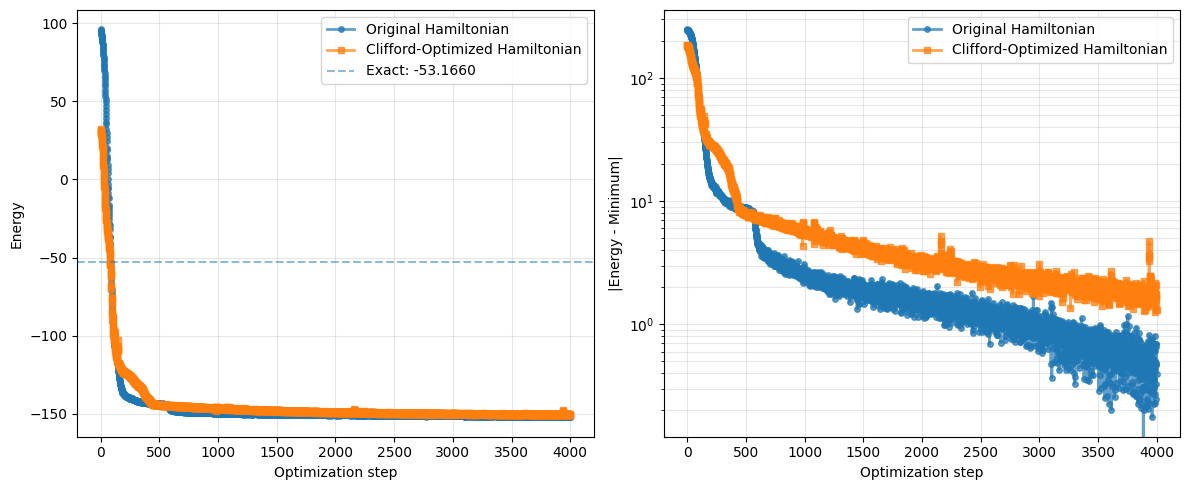

Plot saved as kagome_comparison_N48.png


In [166]:
# Plot convergence comparison
plt.figure(figsize=(12, 5))

# Plot 1: Energy vs iteration
plt.subplot(1, 2, 1)
plt.plot(it_orig, E_orig, 'o-', label="Original Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.plot(it_cliff, E_cliff, 's-', label="Clifford-Optimized Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.axhline(exact_orig, ls="--", color="C0", alpha=0.5, label=f"Exact: {exact_orig:.4f}")
if not np.isclose(exact_cliff, exact_orig):
    plt.axhline(exact_cliff, ls="--", color="C1", alpha=0.5, label=f"Exact (Clifford): {exact_cliff:.4f}")
plt.xlabel("Optimization step")
plt.ylabel("Energy")
plt.legend(loc='best')
plt.grid(True, alpha=0.3)

# Plot 2: Error vs iteration (log scale)
plt.subplot(1, 2, 2)
if N_sites <= 18:
    error_orig = np.abs(E_orig - exact_orig)
    error_cliff = np.abs(E_cliff - exact_cliff)
    label = "|Energy - Exact|"
else:
    e_min = min( min(E_orig), min(E_cliff))
    error_orig = np.abs(E_orig - e_min)  # Use final energy as reference if exact is not available
    error_cliff = np.abs(E_cliff - e_min)
    label = "|Energy - Minimum|"
plt.semilogy(it_orig, error_orig, 'o-', label="Original Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.semilogy(it_cliff, error_cliff, 's-', label="Clifford-Optimized Hamiltonian", linewidth=2, markersize=4, alpha=0.7)
plt.xlabel("Optimization step")
plt.ylabel(label)
plt.legend(loc='best')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig(f"kagome_comparison_N{N_sites}.png", dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved as kagome_comparison_N{}.png".format(N_sites))

In [ ]:
# Analysis
print("\n" + "="*60)
print("Analysis")
print("="*60)

# Calculate convergence rates
def estimate_convergence_rate(energies, exact):
    errors = np.abs(energies - exact)
    errors = errors[errors > 1e-10]  # Filter out numerical noise
    if len(errors) > 1:
        # Simple exponential fit: error ~ exp(-rate * step)
        steps = np.arange(1, len(errors) + 1)
        log_errors = np.log(errors + 1e-12)
        rate = -np.polyfit(steps, log_errors, 1)[0]
        return rate
    return 0

rate_orig = estimate_convergence_rate(E_orig, exact_orig)
rate_cliff = estimate_convergence_rate(E_cliff, exact_cliff)

print(f"\nEstimated convergence rates (exponential decay):")
print(f"  Original Hamiltonian: {rate_orig:.4f}")
print(f"  Clifford-Optimized:   {rate_cliff:.4f}")
if rate_cliff > rate_orig:
    print(f"  Speedup: {rate_cliff/rate_orig:.2f}x faster convergence with Clifford optimization")
elif rate_orig > 0:
    print(f"  Slowdown: {rate_orig/rate_cliff:.2f}x slower convergence with Clifford optimization")

print(f"\nFinal errors:")
print(f"  Original: {error_orig[-1]:.6f}")
print(f"  Clifford: {error_cliff[-1]:.6f}")
if error_cliff[-1] < error_orig[-1]:
    improvement = (error_orig[-1] - error_cliff[-1]) / error_orig[-1] * 100
    print(f"  Improvement: {improvement:.1f}% lower error with Clifford optimization")


Analysis

Estimated convergence rates (exponential decay):
  Original Hamiltonian: 0.0004
  Clifford-Optimized:   0.0003
  Slowdown: 1.32x slower convergence with Clifford optimization

Final errors:
  Original: 0.283046
  Clifford: 0.176366
  Improvement: 37.7% lower error with Clifford optimization
